- overall work flow of this project - we query relevant data from influx - this includes the mppt temperature sensors ad vehicle velocity
- data to be queried from open meteo - every 15 minutes is irradiance, wind speed, ambient temperature
- curve fit to find relevant coefficients needed for the faiman model


From InfluxDB, query data over the first 4 days of FSGP 2025.

In [8]:
from data_tools import query
from data_tools.collections import TimeSeries
from datetime import datetime, date, time, timezone
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dill
import os

#each 5 seconds
utc_offset_h = 7
start_utc = time(12, 00, 00)  #querying is vancouver time, influxdb gives utc
stop_utc = time(00, 00, 00)
date_start = date(2025, 7, 2)
date_stop = date(2025, 7, 6)
start_time = datetime.combine(date_start, start_utc, tzinfo=timezone.utc)
stop_time = datetime.combine(date_stop, stop_utc, tzinfo=timezone.utc)

client = query.DBClient()
temp_array_fsgp: TimeSeries = client.query_time_series(start_time, stop_time, field="MosfetTemperatureA")
speed_kph: TimeSeries = client.query_time_series(start_time, stop_time, "MotorRotatingSpeed")


In [9]:
#save collected data of 15 minutes

import os
import dill

out_dir = os.path.join("../../motor_analysis", "data", "array_temperature_fsgp_2025-07-06")
mosfetA_file_aliter = os.path.join(out_dir, "mosfetA_aliter.bin")

os.makedirs(out_dir, exist_ok=True)

for filepath, data in zip([mosfetA_file_aliter],
                          [temp_array_fsgp]):
    with open(filepath, 'wb') as f:
        dill.dump(data, f)



#time zone matching conventions??

In [10]:
type(temp_array_fsgp)

data_tools.collections.time_series.TimeSeries

In [11]:
#convert to data frame
df_fsgp = pd.DataFrame(temp_array_fsgp)

querying from openmeteo to get solar irradiance data

- this is hourly irradiance over 4 days


In [101]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
params = {
	"latitude": 36.976,
	"longitude": 86.4491,
	"start_date": "2025-07-02",
	"end_date": "2025-07-07",
	"minutely_15": ["temperature_2m", "shortwave_radiation_instant", "wind_speed_10m"],
	"timezone": "America/Chicago",
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process minutely_15 data. The order of variables needs to be the same as requested.
minutely_15 = response.Minutely15()
minutely_15_temperature_2m = minutely_15.Variables(0).ValuesAsNumpy()
minutely_15_shortwave_radiation_instant = minutely_15.Variables(1).ValuesAsNumpy()
minutely_15_wind_speed_10m = minutely_15.Variables(2).ValuesAsNumpy()

minutely_15_data = {"date": pd.date_range(
	start = pd.to_datetime(minutely_15.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(minutely_15.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = minutely_15.Interval()),
	inclusive = "left"
)}

minutely_15_data["temperature_2m"] = minutely_15_temperature_2m
minutely_15_data["shortwave_radiation_instant"] = minutely_15_shortwave_radiation_instant
minutely_15_data["wind_speed_10m"] = minutely_15_wind_speed_10m

minutely_15_dataframe = pd.DataFrame(data = minutely_15_data)
print("\nMinutely15 data\n", minutely_15_dataframe)

Coordinates: 37.0°N 86.5°E
Elevation: 5139.0 m asl
Timezone: b'America/Chicago'b'GMT-6'
Timezone difference to GMT+0: -21600s

Minutely15 data
                          date  temperature_2m  shortwave_radiation_instant  \
0   2025-07-02 06:00:00+00:00           1.487                   505.264526   
1   2025-07-02 06:15:00+00:00           1.587                   516.453796   
2   2025-07-02 06:30:00+00:00           1.787                   527.607666   
3   2025-07-02 06:45:00+00:00           1.937                   528.744202   
4   2025-07-02 07:00:00+00:00           1.987                   526.880981   
..                        ...             ...                          ...   
571 2025-07-08 04:45:00+00:00           4.137                   525.869263   
572 2025-07-08 05:00:00+00:00           4.237                   537.033020   
573 2025-07-08 05:15:00+00:00           4.387                   552.215698   
574 2025-07-08 05:30:00+00:00           4.487                   567.368408  

minutely open meteo data starts at 2 july, 12am and goes to 6 july 22 45
therefore on influx i query for 1 july 10  pm to 6 july 20 45


utc is 2 hours ahead of vancouver

- some preprocessing, including:
- merging everything into a dataframe, with resampling influx data to match openmeteo's frequency

In [104]:
print(merged_df['shortwave_radiation_instant'].describe())


count    316.000000
mean      22.459007
std       10.592769
min        3.096837
25%       14.742397
50%       20.974435
75%       28.357857
max       48.654636
Name: shortwave_radiation_instant, dtype: float64


In [103]:
minutely_15_dataframe['date'].head(20)
print(minutely_15_dataframe['shortwave_radiation_instant'].head(20))


0     505.264526
1     516.453796
2     527.607666
3     528.744202
4     526.880981
5     522.027100
6     513.199951
7     500.415741
8     484.679749
9     465.017517
10    445.389191
11    424.808441
12    401.317627
13    379.828491
14    362.278351
15    352.529755
16    353.420837
17    354.186615
18    346.120880
19    323.533844
Name: shortwave_radiation_instant, dtype: float32


Plot some relevant data. this will further be used to generate the relevant coefficients

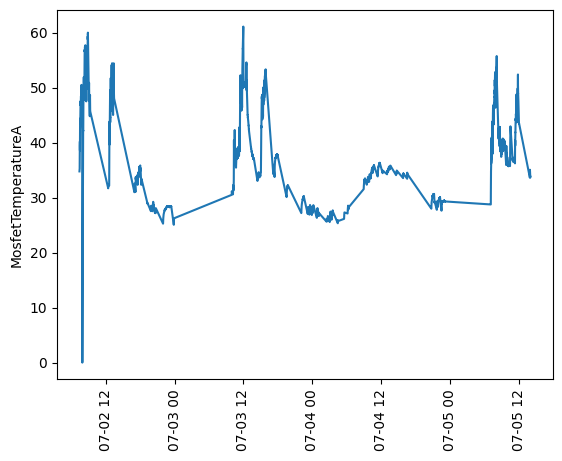

In [15]:
plt.plot(temp_array_fsgp.datetime_x_axis, temp_array_fsgp, label="Array Temperature")
plt.ylabel("MosfetTemperatureA")

plt.tick_params("x", rotation=90)

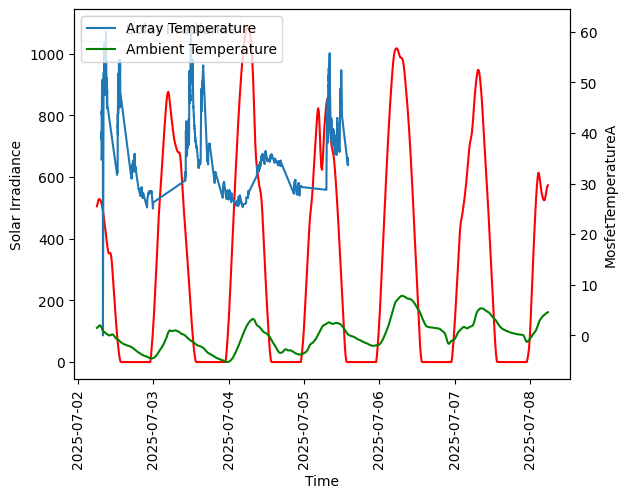

In [105]:
#this graph shows solar irradiance, array temperature, and ambient temperature over July 2-6 (FSGP 2025)

fig, ax1 = plt.subplots()
ax_twin = ax1.twinx()

plt.plot(temp_array_fsgp.datetime_x_axis, temp_array_fsgp, label="Array Temperature")
plt.plot(minutely_15_data['date'], minutely_15_data['temperature_2m'], color='green', label="Ambient Temperature")
ax1.plot(minutely_15_data['date'], minutely_15_data['shortwave_radiation_instant'], color="red",
         label="Solar Irradiance")

ax1.set_xlabel("Time")
ax1.set_ylabel("Solar Irradiance")
ax_twin.set_ylabel("MosfetTemperatureA")

ax1.tick_params("x", rotation=90)

plt.legend(loc="upper left")
ax1.legend(loc="upper left")
plt.show()

In [106]:
#there really isn't Influx data for dates after midday 5 July, so I see no reason to incorporate the OpenMeteo data after

In [107]:
#for easier access, im going to convert everything to a data frame after resampling.
import pandas as pd

#resampling influx data so that i can fit it with irradiance data (queried every 15 minutes)

ts = temp_array_fsgp
timestamps = pd.to_datetime(ts.datetime_x_axis, utc=True)
values = ts.data

df = pd.DataFrame({"value": values}, index=timestamps)
df_15m = df.resample("15T").mean()

print(df_15m.head())


                               value
2025-07-02 07:15:00+00:00  37.371079
2025-07-02 07:30:00+00:00  46.801625
2025-07-02 07:45:00+00:00  29.980004
2025-07-02 08:00:00+00:00  45.573409
2025-07-02 08:15:00+00:00  55.745558


C:\Users\sanar\AppData\Local\Temp\ipykernel_14188\1837817124.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_15m = df.resample("15T").mean()


In [108]:
minutely_15_dataframe.head()
df_15min = minutely_15_dataframe[minutely_15_dataframe['date'] < '2025-07-06']

In [109]:
df_15min.tail()
weather_df = df_15min.copy()

#set datetime as index
weather_df["date"] = pd.to_datetime(weather_df["date"], utc=True)
weather_df = weather_df.set_index("date")
weather_df = weather_df.sort_index()


In [110]:
weather_df.head()

,temperature_2m,shortwave_radiation_instant,wind_speed_10m
date,,,
2025-07-02 06:00:00+00:00,1.487,505.264526,23.688984
2025-07-02 06:15:00+00:00,1.587,516.453796,23.617756
2025-07-02 06:30:00+00:00,1.787,527.607666,23.557316
2025-07-02 06:45:00+00:00,1.937,528.744202,23.507751
2025-07-02 07:00:00+00:00,1.987,526.880981,23.469128


In [111]:
print("Influx 15min index:")
print(df_15m.index[:5])
print(df_15m.index[-5:])

print("Weather index:")
print(weather_df.index[:5])
print(weather_df[-5:])


Influx 15min index:
DatetimeIndex(['2025-07-02 07:15:00+00:00', '2025-07-02 07:30:00+00:00',
               '2025-07-02 07:45:00+00:00', '2025-07-02 08:00:00+00:00',
               '2025-07-02 08:15:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='15min')
DatetimeIndex(['2025-07-05 13:00:00+00:00', '2025-07-05 13:15:00+00:00',
               '2025-07-05 13:30:00+00:00', '2025-07-05 13:45:00+00:00',
               '2025-07-05 14:00:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='15min')
Weather index:
DatetimeIndex(['2025-07-02 06:00:00+00:00', '2025-07-02 06:15:00+00:00',
               '2025-07-02 06:30:00+00:00', '2025-07-02 06:45:00+00:00',
               '2025-07-02 07:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='date', freq=None)
                           temperature_2m  shortwave_radiation_instant  \
date                                                                     
2025-07-05 22:45:00+00:00          -2.013                     0

In [112]:
#sort indices
df_15m_copy = df_15m.copy().sort_index()
weather_df = weather_df.sort_index()

#resampling for 15minute range
df_15m_copy.index = df_15m_copy.index.floor("15T")
weather_df.index = weather_df.index.floor("15T")
#ensure common timestamps
common_index = df_15m_copy.index.intersection(weather_df.index)

print("overlap start:", common_index.min())
print("overlap end:", common_index.max())
print("no of aligned points:", len(common_index))

#merging common timestamps
merged_df = pd.concat(
    [df_15m_copy.loc[common_index], weather_df.loc[common_index]],
    axis=1
)


Overlap start: 2025-07-02 07:15:00+00:00
Overlap end: 2025-07-05 14:00:00+00:00
Number of aligned points: 316


C:\Users\sanar\AppData\Local\Temp\ipykernel_14188\439453639.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_15m_copy.index = df_15m_copy.index.floor("15T")
C:\Users\sanar\AppData\Local\Temp\ipykernel_14188\439453639.py:7: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  weather_df.index = weather_df.index.floor("15T")


In [114]:
merged_df.dropna()

,value,temperature_2m,shortwave_radiation_instant,wind_speed_10m
2025-07-02 07:15:00+00:00,37.371079,1.787,522.027100,23.177401
2025-07-02 07:30:00+00:00,46.801625,1.487,513.199951,22.406927
2025-07-02 07:45:00+00:00,29.980004,1.137,500.415741,21.945240
2025-07-02 08:00:00+00:00,45.573409,0.887,484.679749,21.817902
2025-07-02 08:15:00+00:00,55.745558,0.687,465.017517,21.767351
...,...,...,...,...
2025-07-05 13:00:00+00:00,38.086209,1.137,58.205017,29.548521
2025-07-05 13:15:00+00:00,36.774658,0.887,22.902834,27.475807
2025-07-05 13:30:00+00:00,35.463106,0.637,2.313184,25.202570
2025-07-05 13:45:00+00:00,34.271664,0.437,0.000000,22.461807


In [115]:
merged_df = merged_df.rename(columns={'value': 'array_temperature'})

In [116]:
merged_df.head()

,array_temperature,temperature_2m,shortwave_radiation_instant,wind_speed_10m
2025-07-02 07:15:00+00:00,37.371079,1.787,522.027100,23.177401
2025-07-02 07:30:00+00:00,46.801625,1.487,513.199951,22.406927
2025-07-02 07:45:00+00:00,29.980004,1.137,500.415741,21.945240
2025-07-02 08:00:00+00:00,45.573409,0.887,484.679749,21.817902
2025-07-02 08:15:00+00:00,55.745558,0.687,465.017517,21.767351


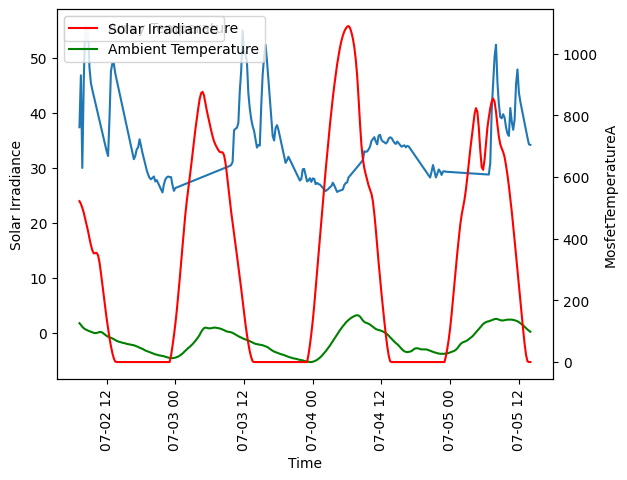

In [117]:
#this graph shows solar irradiance, array temperature, and ambient temperature over July 2-6 (FSGP 2025)

fig, ax1 = plt.subplots()
ax_twin = ax1.twinx()

ax1.plot(merged_df['array_temperature'], label="Array Temperature")
ax1.plot(merged_df['temperature_2m'], color='green', label="Ambient Temperature")
plt.plot(merged_df['shortwave_radiation_instant'], color="red", label="Solar Irradiance")

ax1.set_xlabel("Time")
ax1.set_ylabel("Solar Irradiance")
ax_twin.set_ylabel("MosfetTemperatureA")

ax1.tick_params("x", rotation=90)

plt.legend(loc="upper left")
ax1.legend(loc="upper left")
plt.show()

import the Physics Array Temperature Model for validation/sanity checks


In [140]:
from v4.array_temperature.arrayTemperatureModel import arrayTemperatureModel
import numpy as np
from scipy.optimize import curve_fit


def faiman_model(xdata, u0, u1):
    irradiance, ambient_temp, wind_speed = xdata
    model = arrayTemperatureModel(ambient_temperature=ambient_temp, irradiance=irradiance, wind_speed=wind_speed,
                                  thermal_loss_coefficient=u0, convective_loss_coefficient=u1)
    return model.calculateArrayTemperature()


#xdata, ydata
def fit_faiman(model, xdata, ydata, params):
    popt, _ = curve_fit(model, xdata, ydata, p0=params)

    return popt  # u0, u1


In [141]:
xdata = np.stack([merged_df['shortwave_radiation_instant'], merged_df['temperature_2m'], merged_df['wind_speed_10m']])
faiman_temp = np.array(faiman_model(xdata, 22,0.8))

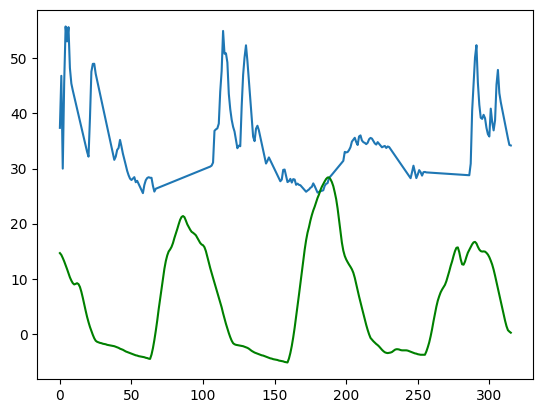

In [142]:
#comparing immediate, unfit results
plt.plot(np.array(merged_df['array_temperature']), label="Array Temperature")
plt.plot(faiman_temp, color="green", label="Modelled Temperature")

clearly, the faiman model peaks too early - which is due to its steady state nature. Also, to note that the MPPT sensors might have a ~5 C discrepancy, but that is iirelevant here as the model is currently, still quite close to ambient temperature. This indicates either an offset change or coefficients. Curve fitting might help for a more decisive result.

In [146]:
params = [22, 0.8]
xdata = np.stack([merged_df['shortwave_radiation_instant'], merged_df['temperature_2m'], merged_df['wind_speed_10m']])
fit_faiman(faiman_model,
           xdata,
           merged_df['array_temperature'], params)

array([19.30085889,  0.07811406])

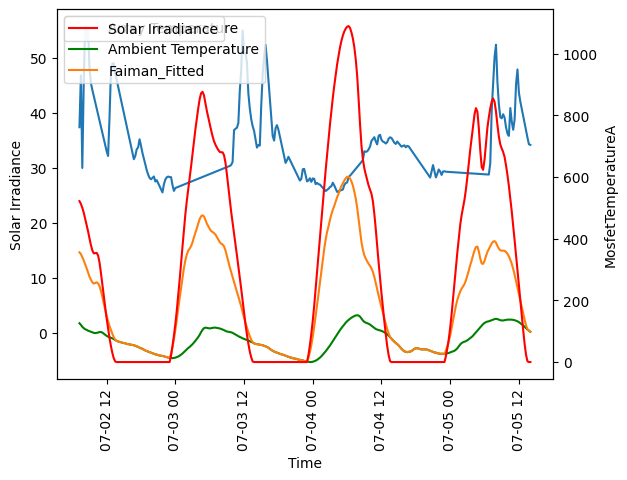

In [152]:
#this graph shows solar irradiance, array temperature, and ambient temperature over July 2-6 (FSGP 2025)

fig, ax1 = plt.subplots()
ax_twin = ax1.twinx()

ax1.plot(merged_df['array_temperature'], label="Array Temperature")
ax1.plot(merged_df['temperature_2m'], color='green', label="Ambient Temperature")
ax1.plot(merged_df.index,faiman_temp, label = "Faiman_Fitted")
plt.plot(merged_df['shortwave_radiation_instant'], color="red", label="Solar Irradiance")

ax1.set_xlabel("Time")
ax1.set_ylabel("Solar Irradiance")
ax_twin.set_ylabel("MosfetTemperatureA")

ax1.tick_params("x", rotation=90)

plt.legend(loc="upper left")
ax1.legend(loc="upper left")
plt.show()

In [ ]:
#trying an offset:

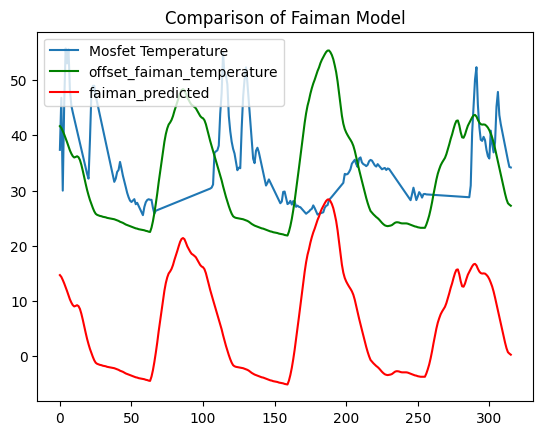

In [134]:
plt.plot(np.array(merged_df['array_temperature']), label="Mosfet Temperature")
plt.plot(faiman_model(xdata, *params) + 27, color = 'green', label = 'offset_faiman_temperature')
plt.plot(faiman_model(xdata, *params), color  ='red', label = 'faiman_predicted')
plt.title("Comparison of Faiman Model")
plt.legend(loc="upper left")
plt.show()

In [ ]:
#the faiman model doesn't seem to take into account the thermal mass i.e. the time it takes for the arrays themselves to heat up. following the appraoch in the paper linked, i used the thermal capacitance approach, namely consideringthe differential equation:
